# 12장 실습 — 관측 갭과 동역학 갭

10장과 11장은 배포 조건을 **한 덩어리**로 다뤘다. 관측 편향, 제어 지연, 마찰 변화가 한꺼번에 걸린 조건이다. 이 노트북은 그 덩어리를 **축별로 풀어** 두 기준 정책이 어느 갭에 약한지 잰다.

- **관측 갭** — 관측 편향. 정책이 보는 것이 세계와 다르다
- **동역학 갭** — 제어 지연과 마찰. 정책이 낸 명령이 세계에서 다르게 실행된다

3권 15장은 「모방 정책은 관측 편향에 약하고 강화학습 정책은 지연에 약하다」고 보고했다. 7장의 두 기준선에 같은 질문을 던진다.

그리고 10장이 미뤄 둔 한계를 잰다. 이 책은 배포 조건 하나를 실기 대역으로 삼았다. **현장이 배포 조건과 조금 달라지면** 정책의 순위가 유지되는가.

끝에서 `gap/sensitivity.json` 을 남긴다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="sorting_cell">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="part" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
SEP, BX = .10, .28                      # 적재함 위치 (m)
MODEL = mujoco.MjModel.from_xml_string(XML)


def bin_xy(k):
    """A형(k=0)은 왼쪽, B형(k=1)은 오른쪽 적재함이다"""
    return np.array([BX, (1 - 2 * k) * SEP])


class Cell:
    """평면 분류 셀 — 부품을 종류에 맞는 칸으로 민다"""

    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.k = np.zeros(n, int)
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        self.k[i] = self.rng.integers(0, 2)
        jit = self.rng.uniform(-.03, .03, 2)
        self.g[i] = bin_xy(self.k[i]) + jit
        b = np.array([bx, by])
        v = self.g[i] - b
        d.qpos[7:9] = b - v / np.linalg.norm(v) * .09
        mujoco.mj_forward(self.m, d)
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.zeros((self.n, 10), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = (self.g[i] - b) * 10.
            o[i, 2:4] = d.qvel[0:2] * 10.
            o[i, 4:6] = (b - d.qpos[7:9]) * 10.
            o[i, 6:8] = d.qvel[6:8] * 10.
            o[i, 8 + self.k[i]] = 1.          # 종류 표시
        return o

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            hit = db < GOAL_R
            if hit or self.t[i] >= EP:
                dn[i] = 1.
                other = bin_xy(1 - self.k[i])
                wrong = np.linalg.norm(d.qpos[0:2] - other) < .06
                sc.append((int(hit), int(wrong), int(self.t[i]),
                           int(self.k[i])))
                self.reset(i)
        return r, dn, sc

In [4]:
class Pert(Cell):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("적재함 A", np.round(bin_xy(0), 2))
print("적재함 B", np.round(bin_xy(1), 2))
print("평가 조건:", ", ".join(COND))

적재함 A [0.28 0.1 ]
적재함 B [ 0.28 -0.1 ]
평가 조건: 명목, 배포


In [5]:
class AC(nn.Module):
    def __init__(self, din=10):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

In [6]:
import os
import csv
import json


def unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > 1e-9, v / np.maximum(n, 1e-9), 0.)


def servo(env):
    """1장의 대본 전문가 — 부품 뒤로 돌아가 적재함 쪽으로 민다"""
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    dv = unit(env.g - b)
    behind = b - dv * .045
    e = behind - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)


COLS = ["cond", "version", "seed", "kind", "success", "wrong",
        "steps"]


def rollout(actfn, cond, seed=999, n=150, reps=3, tag=0, ver="v0"):
    """1장의 로그 스키마 그대로 판마다 한 줄을 남긴다"""
    env = Pert(n, seed, **COND[cond])
    rows = []
    for t in range(EP * reps):
        _, dn, sc = env.step(actfn(env))
        for hit, wrong, steps, k in sc:
            rows.append((cond, ver, tag, "AB"[k], hit, wrong,
                         steps))
    return rows


def rate(rows):
    return sum(r[4] for r in rows) / len(rows)


def bc(X, Y, steps=4000, lr=1e-3, bs=512, seed=2):
    """행동 복제 — 관측에서 라벨로 가는 평균제곱 회귀"""
    torch.manual_seed(seed)
    net = AC(10)
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    Xt = torch.from_numpy(X)
    Yt = torch.from_numpy(Y)
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(X), (bs,), generator=g)
        loss = ((net.pi(Xt[j]) - Yt[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


def mean_act(net):
    """평가는 평균 행동으로 — 복제 정책은 분산을 배우지 않았다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(env.obs())).numpy()
    return f


def save_log(path, rows):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(COLS)
        w.writerows(rows)

In [7]:
import copy

SIG = .22


def dart_eps(count, seed, n=32, cond=None, sig=SIG):
    """잡음 주입 시연을 판 단위로 모은다 (cond: 그 조건의 셀)"""
    rng = np.random.default_rng(seed)
    env = Pert(n, seed, **COND[cond]) if cond else Cell(n, seed)
    cur = [[] for _ in range(n)]
    out = []
    while len(out) < count:
        o = env.obs()
        lab = servo(env)
        act = np.clip(lab + rng.normal(0, sig, lab.shape), -1, 1)
        for i in range(n):
            cur[i].append((o[i], lab[i]))
        dn = env.step(act.astype(np.float32))[1]
        for i in np.flatnonzero(dn):
            out.append(cur[i])
            cur[i] = []
    out = out[:count]
    X = np.array([a for e in out for a, _ in e], np.float32)
    Y = np.array([b for e in out for _, b in e], np.float32)
    return X, Y, np.array([len(e) for e in out])


def load_cell(path="data/cell_v1"):
    """6장의 데이터셋을 읽는다 — 없으면 같은 설정으로 모은다"""
    f = f"{path}/data/chunk-000/file-000.parquet"
    if os.path.exists(f):
        import pyarrow.parquet as pq
        t = pq.read_table(f)
        flat = lambda c: np.asarray(t[c].combine_chunks().flatten())
        X = flat("observation.state").reshape(-1, 10)
        X = X.astype(np.float32)
        Y = flat("action").reshape(-1, 2).astype(np.float32)
        st = json.load(open(f"{path}/meta/stats.json"))
        st = st["observation.state"]
        print(f"{path} 를 읽었다 — {len(X):,} 스텝")
        return X, Y, st
    X, Y, _ = dart_eps(128, seed=1)
    z = X[:, :8] / 10.
    st = {"method": "평균·표준편차", "mean": z.mean(0).tolist(),
          "std": (z.std(0) + 1e-8).tolist()}
    print(f"{path} 가 없다 — 잡음 주입 시연 128판을 모았다")
    return X, Y, st


XS, YS, STATS = load_cell()
MU = np.array(STATS["mean"], np.float32) * 10.   # 셀 척도로
SD = np.array(STATS["std"], np.float32) * 10.


def nz(o):
    """4장의 정규화 — 위치·속도 여덟 차원만 평균·표준편차로"""
    o = o.copy()
    o[:, :8] = (o[:, :8] - MU) / SD
    return o.astype(np.float32)


def pol(net):
    """정규화한 관측으로 평균 행동을 낸다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(nz(env.obs()))).numpy()
    return f


def cycle(rows):
    """성공한 판의 주기 중앙값 (스텝)"""
    st = [r[6] for r in rows if r[4]]
    return float(np.median(st)) if st else float("nan")

data/cell_v1 를 읽었다 — 5,792 스텝


In [8]:
def ppo(budget=250_000, seed=0, init=None, ls=None, lr=3e-3,
        n=16, T=32):
    """1장의 PPO + 4장의 정규화 — init 을 주면 이어서 학습"""
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC() if init is None else init
    if ls is not None:
        ac.ls.data[:] = ls
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = nz(env.obs())
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = nz(env.obs())
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

## 두 기준 정책, 시드 셋

행동 복제는 6장의 데이터로 시드 셋을 새로 학습한다(시드 0은 7장의 `policy/bc_v1.pt` 와 같다). 강화학습은 7장의 `policy/rl_v1.pt` 를 시드 0으로 쓰고 시드 1·2를 새로 학습한다.

In [9]:
XN = nz(XS)
POL = {"행동 복제": [bc(XN, YS, seed=s) for s in (0, 1, 2)]}
t0 = time.time()
rl0 = (torch.load("policy/rl_v1.pt", weights_only=False)
       if os.path.exists("policy/rl_v1.pt") else ppo(seed=0))
POL["강화학습"] = [rl0, ppo(seed=1), ppo(seed=2)]
print(f"정책 준비 끝 ({time.time() - t0:.0f}s)")

정책 준비 끝 (145s)


## 한 축씩 흔든다

나머지 축은 명목에 두고 한 축만 바꾼다. 편향은 배포 조건의 방향 (6, −4) mm 를 0배에서 3배까지 키운다.

| 축 | 갭의 종류 | 값 |
|---|---|---|
| 관측 편향 | 관측 | (6, −4) mm × 0, 0.5, 1, 2, 3 |
| 제어 지연 | 동역학 | 0, 1, 2, 3주기 |
| 마찰 | 동역학 | 0.4, 0.6, 0.8, 1.0, 1.2 |

In [10]:
AXES = {"관측 편향": [0, .5, 1, 2, 3],
        "제어 지연": [0, 1, 2, 3],
        "마찰": [.4, .6, .8, 1., 1.2]}


def cond_of(ax, v):
    if ax == "관측 편향":
        return dict(bias=(.006 * v, -.004 * v))
    if ax == "제어 지연":
        return dict(lat=v)
    return dict(mu=v)


EV = dict(n=60, reps=2)
LOG, SENS = [], {}
t0 = time.time()
for ax, vals in AXES.items():
    for v in vals:
        COND["_c"] = cond_of(ax, v)
        for k, nets in POL.items():
            rs = []
            for s, net in enumerate(nets):
                rows = rollout(pol(net), "_c", tag=s,
                               ver=f"sens-{k}-{ax}-{v}", **EV)
                LOG.extend(rows)
                rs.append(rate(rows))
            SENS[(k, ax, v)] = rs
    print(f"  {ax} 끝  ({time.time() - t0:.0f}s)", flush=True)

for ax, vals in AXES.items():
    print(f"\n{ax}")
    print(pad("값", 8) + "".join(pad(k, 20, True) for k in POL))
    for v in vals:
        cells = [f"{np.mean(SENS[(k, ax, v)]):.3f} "
                 f"[{min(SENS[(k, ax, v)]):.2f}, "
                 f"{max(SENS[(k, ax, v)]):.2f}]" for k in POL]
        print(pad(f"{v:g}", 8)
              + "".join(pad(c, 20, True) for c in cells))

  관측 편향 끝  (67s)


  제어 지연 끝  (117s)


  마찰 끝  (185s)



관측 편향
값                 행동 복제            강화학습
0         1.000 [1.00, 1.00]  0.997 [0.99, 1.00]
0.5       1.000 [1.00, 1.00]  0.943 [0.85, 1.00]
1         0.977 [0.95, 1.00]  0.669 [0.58, 0.79]
2         0.289 [0.12, 0.49]  0.022 [0.00, 0.06]
3         0.151 [0.00, 0.25]  0.000 [0.00, 0.00]

제어 지연
값                 행동 복제            강화학습
0         1.000 [1.00, 1.00]  0.997 [0.99, 1.00]
1         1.000 [1.00, 1.00]  0.825 [0.76, 0.92]
2         0.698 [0.56, 0.84]  0.149 [0.03, 0.22]
3         0.128 [0.08, 0.16]  0.064 [0.02, 0.13]

마찰
값                 행동 복제            강화학습
0.4       1.000 [1.00, 1.00]  0.647 [0.26, 0.88]
0.6       1.000 [1.00, 1.00]  0.997 [0.99, 1.00]
0.8       1.000 [1.00, 1.00]  0.929 [0.87, 0.97]
1         0.999 [1.00, 1.00]  0.640 [0.48, 0.77]
1.2       0.993 [0.99, 1.00]  0.421 [0.30, 0.53]


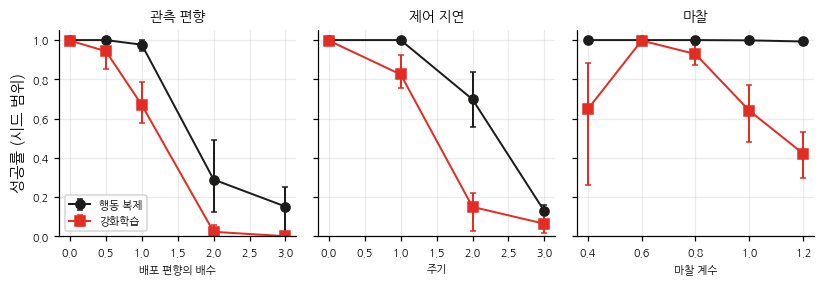

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(7.6, 2.7), sharey=True)
for a, (ax, vals) in zip(axs, AXES.items()):
    for k, col, mk in (("행동 복제", INK, "o"),
                       ("강화학습", RED, "s")):
        m = np.array([np.mean(SENS[(k, ax, v)]) for v in vals])
        lo = m - np.array([min(SENS[(k, ax, v)]) for v in vals])
        hi = np.array([max(SENS[(k, ax, v)]) for v in vals]) - m
        a.errorbar(vals, m, yerr=[lo, hi], color=col, marker=mk,
                   capsize=2, lw=1.3, label=k)
    a.set_title(ax, fontsize=9)
    a.tick_params(labelsize=7)
axs[0].set_ylabel("성공률 (시드 범위)")
axs[0].set_ylim(0, 1.05)
axs[0].legend(fontsize=7, loc="lower left")
axs[0].set_xlabel("배포 편향의 배수", fontsize=7)
axs[1].set_xlabel("주기", fontsize=7)
axs[2].set_xlabel("마찰 계수", fontsize=7)
plt.tight_layout()
plt.show()

## 두 갭을 함께 — 민감도 지도

관측 편향(0~3배)과 제어 지연(0~3주기)을 함께 바꿔 지도를 그린다. 마찰은 명목이다. 시드 0의 정책만 쓴다.

(67s)


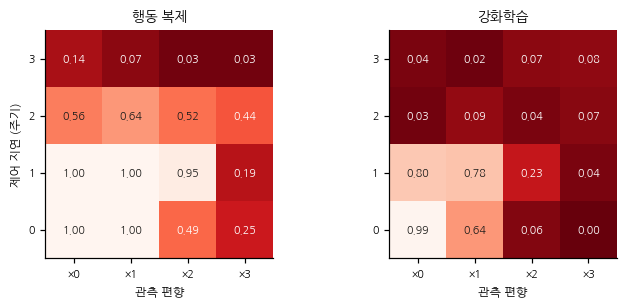

In [12]:
BS, LS = [0, 1, 2, 3], [0, 1, 2, 3]
MAP = {}
t0 = time.time()
for k, nets in POL.items():
    M = np.zeros((len(LS), len(BS)))
    for i, lt in enumerate(LS):
        for j, b in enumerate(BS):
            COND["_c"] = dict(bias=(.006 * b, -.004 * b), lat=lt)
            rows = rollout(pol(nets[0]), "_c", ver=f"map-{k}", **EV)
            LOG.extend(rows)
            M[i, j] = rate(rows)
    MAP[k] = M
print(f"({time.time() - t0:.0f}s)")

fig, axs = plt.subplots(1, 2, figsize=(6.6, 2.9))
for a, (k, M) in zip(axs, MAP.items()):
    im = a.imshow(M, origin="lower", cmap="Reds_r", vmin=0, vmax=1)
    for i in range(len(LS)):
        for j in range(len(BS)):
            tc = INK if M[i, j] > .5 else "white"
            a.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                   fontsize=7, color=tc)
    a.set_xticks(range(len(BS)))
    a.set_xticklabels([f"×{b}" for b in BS], fontsize=7)
    a.set_yticks(range(len(LS)))
    a.set_yticklabels(LS, fontsize=7)
    a.set_xlabel("관측 편향", fontsize=8)
    a.set_title(k, fontsize=9)
    a.grid(False)
axs[0].set_ylabel("제어 지연 (주기)", fontsize=8)
plt.tight_layout()
plt.show()

## 대역은 어디서 깨지는가

배포 조건 하나를 실기 대역으로 삼았다. 실제 현장은 그 조건과 조금씩 다를 것이다. 편향 ±10 mm, 지연 0~2주기, 마찰 0.5~1.1에서 **현장 스무 곳**을 무작위로 뽑아, 두 기준 정책(시드 0)과 9장의 혼합 정책을 잰다.

배포 조건에서의 순위는 혼합 > 행동 복제 > 강화학습이었다. 스무 현장 가운데 몇 곳에서 이 순위가 유지되는가.

In [13]:
MIX = (torch.load("policy/mix_v1.pt", weights_only=False)
       if os.path.exists("policy/mix_v1.pt") else None)
TRIO = {"혼합": MIX, "행동 복제": POL["행동 복제"][0],
        "강화학습": POL["강화학습"][0]}
TRIO = {k: v for k, v in TRIO.items() if v is not None}
rng = np.random.default_rng(7)
SITES, SITE_SC = [], []
t0 = time.time()
for s in range(20):
    p = dict(bias=tuple(rng.uniform(-.01, .01, 2)),
             lat=int(rng.integers(0, 3)),
             mu=float(rng.uniform(.5, 1.1)))
    COND["_c"] = p
    SITES.append(p)
    sc = {}
    for k, net in TRIO.items():
        rows = rollout(pol(net), "_c", seed=900 + s,
                       ver=f"site-{k}", n=40, reps=2)
        LOG.extend(rows)
        sc[k] = rate(rows)
    SITE_SC.append(sc)
del COND["_c"]
print(f"({time.time() - t0:.0f}s)\n")
order = list(TRIO)
keep = sum(all(sc[order[i]] >= sc[order[i + 1]]
               for i in range(len(order) - 1)) for sc in SITE_SC)
print(pad("현장", 6) + pad("편향 mm", 14, True)
      + pad("지연", 6, True) + pad("마찰", 6, True)
      + "".join(pad(k, 10, True) for k in order))
for i, (p, sc) in enumerate(zip(SITES, SITE_SC)):
    b = f"({p['bias'][0] * 1e3:+.0f}, {p['bias'][1] * 1e3:+.0f})"
    print(pad(i, 6) + pad(b, 14, True) + pad(p["lat"], 6, True)
          + pad(f"{p['mu']:.2f}", 6, True)
          + "".join(pad(f"{sc[k]:.2f}", 10, True) for k in order))
print(f"\n배포 조건의 순위({' > '.join(order)})가 유지된 현장: "
      f"{keep}/{len(SITE_SC)}")
for k in order:
    v = [sc[k] for sc in SITE_SC]
    print(f"  {pad(k, 10)} 평균 {np.mean(v):.3f} 최저 {min(v):.2f}")

(90s)

현장         편향 mm  지연  마찰      혼합 행동 복제  강화학습
0           (+3, +8)     1  0.64      0.94      0.92      0.20
1           (-4, +7)     2  0.50      0.00      0.31      0.03
2           (+6, +6)     0  0.68      0.24      0.72      0.11
3           (-4, -5)     1  0.77      0.79      0.60      0.61
4           (+0, +1)     1  0.98      0.99      0.99      0.72
5          (+2, +10)     2  0.63      0.00      0.59      0.10
6           (-7, +2)     0  0.52      1.00      0.98      0.93
7           (+0, -1)     0  1.05      1.00      1.00      0.65
8           (+3, +0)     0  0.65      1.00      1.00      0.99
9          (-10, -6)     1  0.92      0.01      0.23      0.22
10          (-6, -3)     1  1.00      0.73      0.65      0.52
11          (-7, -5)     0  1.03      0.23      0.39      0.62
12          (+0, +7)     2  0.95      0.01      0.74      0.05
13          (-8, +1)     1  0.80      0.99      0.82      0.56
14          (+7, -3)     1  0.54      1.00      1.00      0.88
15 

## 민감도를 남긴다

두 정책의 축별 민감도 — 명목 값에서 가장 나쁜 값까지 떨어진 폭 — 를 적는다. 5부가 이 수를 읽어 어느 갭에 대응 층을 먼저 붙일지 정한다.

In [14]:
OUT = {"axes": {ax: vals for ax, vals in AXES.items()}, "drop": {},
       "sites_rank_kept": f"{keep}/{len(SITE_SC)}"}
print(pad("정책", 12) + "".join(pad(ax, 12, True) for ax in AXES))
for k in POL:
    row = {}
    for ax, vals in AXES.items():
        ms = [np.mean(SENS[(k, ax, v)]) for v in vals]
        i0 = vals.index(0) if 0 in vals else vals.index(.6)
        base = ms[i0]
        row[ax] = round(float(base - min(ms)), 3)
    OUT["drop"][k] = row
    print(pad(k, 12) + "".join(pad(f"{row[ax]:.3f}", 12, True)
                               for ax in AXES))
os.makedirs("gap", exist_ok=True)
with open("gap/sensitivity.json", "w") as f:
    json.dump(OUT, f, ensure_ascii=False, indent=1)
save_log("report/ch12_log.csv", LOG)
print()
print("남긴 산출물")
print("  gap/sensitivity.json  축별 민감도, 현장 스무 곳의 순위")
print(f"  report/ch12_log.csv   판별 로그 {len(LOG):,}줄")

정책           관측 편향   제어 지연        마찰
행동 복제          0.849       0.872       0.007
강화학습           0.997       0.934       0.577

남긴 산출물
  gap/sensitivity.json  축별 민감도, 현장 스무 곳의 순위
  report/ch12_log.csv   판별 로그 34,841줄


## 정리

**복제는 동역학 중 마찰에 무감하고, 강화학습은 마찰에도 약하다.** 두 정책을 가르는 축은 마찰이었다. 편향과 지연에는 둘 다 약하고, 강화학습이 먼저 무너진다.

**두 갭은 더해지지 않는다.** 한 축씩 잰 민감도로 두 축을 함께 흔든 결과를 예측할 수 없다.

**실기 대역 하나의 순위는 스무 현장 가운데 9곳에서만 유지됐다.** 대역에 맞춘 혼합 정책은 스무 현장 평균에서 행동 복제보다 낮았다.

**5부가 읽을 수는 `gap/sensitivity.json` 에 남겼다.** 복제를 주 정책으로 쓴다면 대응 층은 **지연 2주기와 편향 2배**라는 두 문턱을 넘지 않게 하는 데 집중하면 된다.